### [Casual Inference: Regression Discontinuity Design](https://medium.com/causal-inference-methods-models-and-applications/regression-discontinuity-design-rdd-c739e05bc23c)

#### Bandwidth Selection in RDD
Below are three popular methods: **IK (Imbens–Kalyanaraman)**, **CV (Cross-Validation)**, and **CCT (Calonico-Cattaneo-Titiunik)**. CCT often considered the modern default because of its bias correction and inference properties.

1. *Imbens–Kalyanaraman (IK) Method (Imbens & Kalyanaraman, 2012)*

The IK method is a formula-based approach for selecting the optimal bandwidth. It offers a rule-of-thumb for bandwidth choice that balances bias and variance under standard RDD assumptions.

2. *Cross-Validation (CV) Method (Ludwig & Miller, 2007; Imbens & Lemieux, 2008)*

CV is a data-driven approach that selects the bandwidth by minimizing prediction error using a leave-one-out cross-validation procedure. The motivation behind CV is to adapt bandwidth selection to the actual data distribution.

3. *Calonico-Cattaneo-Titiunik (CCT) Method (Calonico et al., 2014)*

In RDD, the bandwidth determines how much data is included near the cutoff. Calonico et al. address the trade-off between variance and bias.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

np.random.seed(2025)
plt.style.use("seaborn-v0_8-whitegrid")

import warnings
warnings.filterwarnings("ignore")

In [2]:
# -------------------------------------------------
# 1) Define the running variable and cutoff; build data
# -------------------------------------------------
# Synthetic population: ages 75–85 years
n = 20000
age_years = np.random.uniform(75, 85, size=n)
age_months = (age_years * 12).astype(int)
age = age_months / 12.0

# Running variable centered at 80 years (cutoff = 0)
running = age - 80.0
elig = (age >= 80.0).astype(int)  # eligibility indicator (instrument)

# Covariates
sex_male = np.random.binomial(1, 0.48, size=n)          # 1 = male
comorbidity = np.random.poisson(1.0, size=n)            # comorbidity index
imd = np.random.choice([1,2,3,4,5], size=n,
                       p=[0.15,0.2,0.3,0.2,0.15])      # deprivation quintile

# Logistic helper
def logistic(x):
    return 1 / (1 + np.exp(-x))

# Vaccination probability: age slope + jump at cutoff
p_vax = logistic(-2.0 + 0.06 * running + 1.6 * elig
                 - 0.05 * comorbidity + 0.12*(imd==5))
vaccinated = np.random.binomial(1, p_vax)

# Mortality probability: increases with age, comorbidity, IMD; reduced by vaccination
logodds_death = -4.0 + 0.25 * running + 0.9 * comorbidity + 0.35*(imd==5) - 1.2 * vaccinated
p_death = logistic(logodds_death)
death = np.random.binomial(1, p_death)

# Assemble dataframe and restrict window
df = pd.DataFrame({
    "age_years": age,
    "running": running,
    "elig": elig,
    "vaccinated": vaccinated,
    "p_vax": p_vax,
    "death": death,
    "p_death": p_death,
    "sex_male": sex_male,
    "comorbidity": comorbidity,
    "imd": imd
})

# Peek through dataframe
print("Original dataframe:\n")
display(df.sample(10))

# Keep analysis window 75–85 years
df_rd = df.loc[df["age_years"].between(75, 85, inclusive="both")].copy()
df_rd["running_sq"] = df_rd["running"] ** 2 # Squared
display(df_rd.sample(10))

Original dataframe:



,age_years,running,elig,vaccinated,p_vax,death,p_death,sex_male,comorbidity,imd
8762,76.333333,-3.666667,0,0,0.093638,0,0.017694,1,1,1
19810,84.916667,4.916667,1,1,0.436593,1,0.219115,1,3,3
17292,76.166667,-3.833333,0,0,0.088669,0,0.040764,1,2,3
13214,79.250000,-0.750000,0,0,0.114559,0,0.014957,0,0,3
17222,82.666667,2.666667,1,0,0.415809,0,0.177507,0,2,4
2271,81.833333,1.833333,1,1,0.403717,0,0.050132,0,2,2
109,78.333333,-1.666667,0,0,0.104331,0,0.028842,1,1,4
12592,82.833333,2.833333,1,1,0.406127,1,0.142869,1,3,3
5869,81.083333,1.083333,1,1,0.404922,0,0.017478,1,1,1
14789,78.333333,-1.666667,0,1,0.095349,0,0.051336,0,3,3


,age_years,running,elig,vaccinated,p_vax,death,p_death,sex_male,comorbidity,imd,running_sq
11292,80.333333,0.333333,1,0,0.394126,1,0.046679,1,1,1,0.111111
16378,82.416667,2.416667,1,1,0.424336,0,0.024225,0,1,3,5.840278
9159,80.000000,0.000000,1,0,0.401312,0,0.017986,0,0,3,0.000000
18433,84.333333,4.333333,1,0,0.452642,0,0.117464,0,1,2,18.777778
5039,83.666667,3.666667,1,0,0.418241,0,0.405323,1,3,1,13.444444
7240,81.333333,1.333333,1,0,0.420676,0,0.024924,1,0,3,1.777778
11803,79.583333,-0.416667,0,0,0.116603,0,0.016236,0,0,3,0.173611
18579,81.000000,1.000000,1,1,0.403717,0,0.017124,1,1,4,1.000000
14767,79.500000,-0.500000,0,0,0.111056,0,0.038236,1,1,1,0.250000
8637,83.583333,3.583333,1,0,0.441519,0,0.099377,0,1,1,12.840278


In [3]:
df_rd.describe()

,age_years,running,elig,vaccinated,p_vax,death,p_death,sex_male,comorbidity,imd,running_sq
count,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,79.959288,-0.040713,0.49835,0.265100,0.264943,0.059200,0.059787,0.480350,1.011400,3.002000,8.249045
std,2.871898,2.871898,0.50001,0.441397,0.165103,0.236005,0.085258,0.499626,1.001759,1.256971,7.440040
min,75.000000,-5.000000,0.00000,0.000000,0.072426,0.000000,0.001578,0.000000,0.000000,1.000000,0.000000
25%,77.500000,-2.500000,0.00000,0.000000,0.101106,0.000000,0.014653,0.000000,0.000000,2.000000,1.562500
50%,79.916667,-0.083333,0.00000,0.000000,0.130108,0.000000,0.030769,0.000000,1.000000,3.000000,6.250000
75%,82.416667,2.416667,1.00000,1.000000,0.429228,0.000000,0.067810,1.000000,2.000000,4.000000,14.062500
max,84.916667,4.916667,1.00000,1.000000,0.503750,1.000000,0.936780,1.000000,7.000000,5.000000,25.000000


In [4]:
# ------------------------------
# First-stage strength
# ------------------------------
X_fs = sm.add_constant(df_rd[["elig", "running", "running_sq"]])
fs_model = sm.OLS(df_rd["vaccinated"], X_fs).fit(cov_type="HC1")
df_rd["vax_hat"] = fs_model.predict(X_fs)
display(fs_model.summary().tables[1])

,coef,std err,z,P>|z|,[0.025,0.975]
const,0.1210,0.006,21.546,0.000,0.110,0.132
elig,0.2817,0.012,24.387,0.000,0.259,0.304
running,0.0098,0.002,4.876,0.000,0.006,0.014
running_sq,0.0005,0.000,1.274,0.203,-0.000,0.001


In [5]:
X_rf = sm.add_constant(df_rd[["elig", "running", "running_sq"]])
rf_model = sm.OLS(df_rd["death"], X_rf).fit(cov_type="HC1")
display(rf_model.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  death   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     87.54
Date:                Fri, 19 Dec 2025   Prob (F-statistic):           2.85e-56
Time:                        15:53:04   Log-Likelihood:                 646.51
No. Observations:               20000   AIC:                            -1285.
Df Residuals:                   19996   BIC:                            -1253.
Df Model:                           3                                         
Covariance Type:                  HC1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0552      0.004     15.446      0.000       0.048       0.062
elig          -0.0062      0.006     -0.986      0.324      -0.018       0.006
running        0.0106      0.001      9.240      0.000       0.008       0.013
running_sq     0.0009      0.000      4.040      0.000       0.000       0.001
==============================================================================
Omnibus:                    14588.264   Durbin-Watson:                   2.006
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           157011.450
Skew:                           3.654   Prob(JB):                         0.00
Kurtosis:                      14.619   Cond. No.                         50.6
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [6]:
#################
# IK bandwidth
#################
def ik_bandwidth(running, outcome):
    n = len(running)
    X_poly = np.column_stack([running, running**2, running**3])
    X_poly = sm.add_constant(X_poly)
    model_poly = sm.OLS(outcome, X_poly).fit()
    second_deriv = 2 * model_poly.params[2]
    sigma2 = np.var(model_poly.resid)
    C = (720 * sigma2) / (n * (second_deriv**2 + 1e-12))
    h_ik = max(C, 1e-12)**(1/5)
    return h_ik

h_ik = ik_bandwidth(df_rd["running"].values, df_rd["death"].values)
print(f"IK bandwidth: {h_ik:.3f} years")

IK bandwidth: 3.561 years


In [7]:
################
# CV bandwidth (leave-one-out OLS on reduced-form within candidate h)
################
def cv_bandwidth(data, outcome, regressors, h_grid):
    best_h = h_grid[0]
    min_mse = np.inf
    for h in h_grid:
        subset = data[np.abs(data["running"]) <= h].copy()
        n_subset = len(subset)
        if n_subset < 50:
            continue
        X = sm.add_constant(subset[regressors], has_constant='add')
        mse = 0.0
        for i in range(n_subset):
            X_loo = np.delete(X.values, i, axis=0)
            y_loo = np.delete(subset[outcome].values, i)
            model = sm.OLS(y_loo, X_loo).fit()
            y_hat_i = model.predict(X.values[i:i+1])
            mse += (subset[outcome].values[i] - y_hat_i[0])**2
        mse /= n_subset
        if mse < min_mse:
            min_mse = mse
            best_h = h
    return best_h

# Define h_grid for CV and CCT bandwidth calculations
h_grid = np.linspace(0.5, 4.0, 50) # Example grid, adjust as needed

h_cv = cv_bandwidth(df_rd, outcome="death", regressors=["elig", "running", "running_sq"], h_grid=h_grid)
print(f"CV bandwidth: {h_cv:.3f} years")

CV bandwidth: 0.500 years


In [8]:
def triangular_weights(x, h, cutoff=0.0):
    d = np.abs(x - cutoff)
    w = np.clip(1.0 - d / h, 0.0, 1.0)
    w[d > h] = 0.0
    return w

In [9]:
# Unweighted local linear (for display / baseline)
def local_linear_ols(data, outcome, regressors, h, cutoff=0.0):
    subset = data[np.abs(data["running"] - cutoff) <= h].copy()
    if len(subset) < 30:
        return np.nan, np.nan, 0, None
    X = sm.add_constant(subset[regressors], has_constant='add')
    model = sm.OLS(subset[outcome], X).fit(cov_type="HC1")
    return model.params, model.bse, len(subset), model

In [10]:
def local_linear_wls(data, outcome, h, cutoff=0.0, include_quad=False, treatment_name="elig"):
    subset = data[np.abs(data["running"] - cutoff) <= h].copy()
    if len(subset) < 30:
        return np.nan, np.nan, 0, None
    subset["x"] = subset["running"] - cutoff
    cols = ["x", treatment_name]
    if include_quad:
        subset["x2"] = subset["x"]**2
        cols.append("x2")
    X = sm.add_constant(subset[cols], has_constant='add')
    w = triangular_weights(subset["running"].values, h, cutoff)
    model = sm.WLS(subset[outcome], X, weights=w).fit(cov_type="HC1")
    tau = model.params[treatment_name]
    se_tau = model.bse[treatment_name]
    n_eff = w.sum()
    return tau, se_tau, n_eff, model

In [11]:
# Second derivatives via local quadratic WLS on each side
def second_derivatives_wls(data, outcome, h, cutoff=0.0):
    subset = data[np.abs(data["running"] - cutoff) <= h].copy()
    subset["x"] = subset["running"] - cutoff

    # Left
    left = subset[subset["x"] < 0].copy()
    d2_left = 0.0
    if len(left) >= 20:
        Xl = sm.add_constant(np.column_stack([left["x"].values, left["x"].values**2]))
        wl = triangular_weights(left["running"].values, h, cutoff)
        ml = sm.WLS(left[outcome].values, Xl, weights=wl).fit()
        d2_left = 2.0 * ml.params[2]

    # Right
    right = subset[subset["x"] >= 0].copy()
    d2_right = 0.0
    if len(right) >= 20:
        Xr = sm.add_constant(np.column_stack([right["x"].values, right["x"].values**2]))
        wr = triangular_weights(right["running"].values, h, cutoff)
        mr = sm.WLS(right[outcome].values, Xr, weights=wr).fit()
        d2_right = 2.0 * mr.params[2]

    delta = d2_right - d2_left
    return d2_left, d2_right, delta

In [12]:
# CCT-style bandwidth via AMSE(h) ≈ sigma^2/(n_eff h) + ((Delta/2)^2) h^4
def cct_bandwidth(data, outcome, h_grid, cutoff=0.0):
    best_h, best_obj = h_grid[0], np.inf
    for h in h_grid:
        subset = data[np.abs(data["running"] - cutoff) <= h].copy()
        if len(subset) < 50:
            continue
        tau_ll, se_ll, n_eff, m_ll = local_linear_wls(data, outcome=outcome, h=h, cutoff=cutoff, include_quad=False, treatment_name="elig")
        if m_ll is None:
            continue
        resid = m_ll.resid
        w = triangular_weights(subset["running"].values, h, cutoff)
        sigma2 = np.average(resid**2, weights=w)
        _, _, Delta = second_derivatives_wls(data, outcome=outcome, h=h, cutoff=cutoff)
        var_term = sigma2 / max(n_eff * h, 1e-8)
        bias_term_sq = (Delta**2 / 4.0) * (h**4)
        obj = var_term + bias_term_sq
        if obj < best_obj:
            best_obj = obj
            best_h = h
    return best_h

In [13]:
h_cct = cct_bandwidth(df_rd, outcome="death", h_grid=h_grid, cutoff=0.0)
print(f"CCT bandwidth: {h_cct:.3f} years")

CCT bandwidth: 0.786 years


In [14]:
# RBC estimate for reduced-form or first-stage
def rbc_estimate(data, outcome, h, cutoff=0.0):
    tau_ll, se_ll, n_eff, _ = local_linear_wls(data, outcome=outcome, h=h, cutoff=cutoff, include_quad=False, treatment_name="elig")
    _, _, Delta = second_derivatives_wls(data, outcome=outcome, h=h, cutoff=cutoff)
    bias_hat = (Delta / 2.0) * (h**2)
    tau_rbc = tau_ll - bias_hat
    return tau_rbc, tau_ll, se_ll, n_eff, bias_hat

In [15]:
# Local linear WLS estimates at chosen CCT bandwidth
rf_tau_rbc, rf_tau_ll, rf_se_ll, rf_n_eff, rf_bias_hat = rbc_estimate(df_rd, outcome="death", h=h_cct)
fs_tau_rbc, fs_tau_ll, fs_se_ll, fs_n_eff, fs_bias_hat = rbc_estimate(df_rd, outcome="vaccinated", h=h_cct)

# LATE via Wald using LL estimates (and RBC variant)
wald_late_ll = rf_tau_ll / fs_tau_ll if fs_tau_ll != 0 else np.nan
wald_late_rbc = rf_tau_rbc / fs_tau_rbc if fs_tau_rbc != 0 else np.nan

# Put in a table
rows = [{
        "Component": "Reduced-form (elig → death)",
        "LL τ": rf_tau_ll,
        "SE": rf_se_ll,
        "Biaŝ": rf_bias_hat,
        "RBC τ": rf_tau_rbc,
        "n_eff": int(round(rf_n_eff))},
    {   "Component": "First-stage (elig → vaccinated)",
        "LL τ": fs_tau_ll,
        "SE": fs_se_ll,
        "Biaŝ": fs_bias_hat,
        "RBC τ": fs_tau_rbc,
        "n_eff": int(round(fs_n_eff)) }]
tbl = pd.DataFrame(rows)
display(tbl)

,Component,LL τ,SE,Biaŝ,RBC τ,n_eff
0,Reduced-form (elig → death),-0.037516,0.015194,0.001091,-0.038607,1626
1,First-stage (elig → vaccinated),0.334155,0.032591,-0.069597,0.403752,1626


In [16]:
# Add Wald LATEs as a separate small table or append footnote text
wald_tbl = pd.DataFrame({
    "Estimator": ["Wald LATE (LL)", "Wald LATE (RBC)"],
    "Value": [wald_late_ll, wald_late_rbc]  })
display(wald_tbl)

,Estimator,Value
0,Wald LATE (LL),-0.112272
1,Wald LATE (RBC),-0.095621


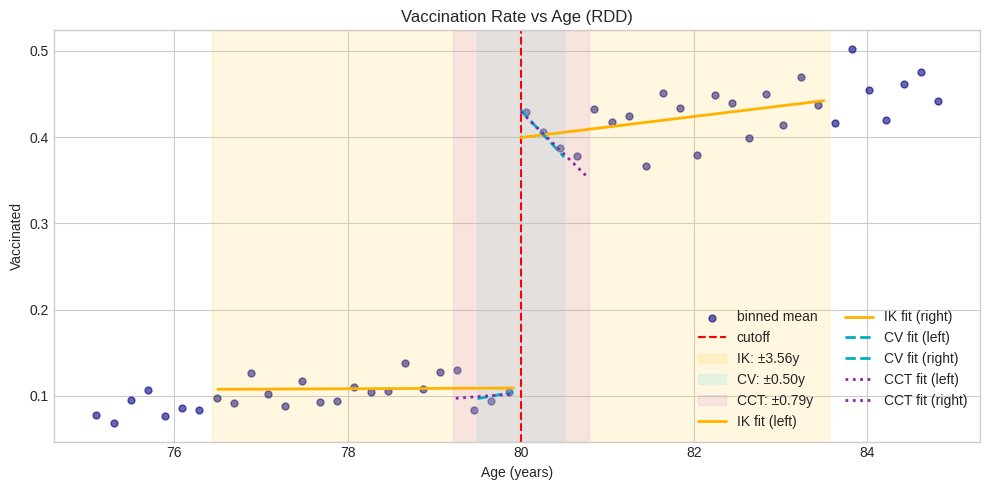

In [17]:
# -------------------------------------------------
# Fitted lines: local linear WLS on each side for a given bandwidth
# -------------------------------------------------
def fit_lines_for_bandwidth(ax, data, outcome, h, cutoff=0.0, color="#333", linestyle="-", label_prefix=""):
    subset = data[np.abs(data["running"] - cutoff) <= h].copy()
    subset["x"] = subset["running"] - cutoff

    # Left side
    left = subset[subset["x"] < 0].copy()
    if len(left) >= 20:
        Xl = sm.add_constant(left[["x"]])
        wl = triangular_weights(left["running"].values, h, cutoff)
        ml = sm.WLS(left[outcome].values, Xl, weights=wl).fit()
        left_sorted = left.sort_values("age_years")
        Xl_pred = sm.add_constant(left_sorted[["x"]])
        yl_pred = ml.predict(Xl_pred)
        ax.plot(left_sorted["age_years"], yl_pred, color=color, linestyle=linestyle, linewidth=2,
                label=f"{label_prefix} fit (left)")

    # Right side
    right = subset[subset["x"] >= 0].copy()
    if len(right) >= 20:
        Xr = sm.add_constant(right[["x"]])
        wr = triangular_weights(right["running"].values, h, cutoff)
        mr = sm.WLS(right[outcome].values, Xr, weights=wr).fit()
        right_sorted = right.sort_values("age_years")
        Xr_pred = sm.add_constant(right_sorted[["x"]])
        yr_pred = mr.predict(Xr_pred)
        ax.plot(right_sorted["age_years"], yr_pred, color=color, linestyle=linestyle, linewidth=2,
                label=f"{label_prefix} fit (right)")

# -------------------------------------------------
# Helper for binned scatter (visual guide)
# -------------------------------------------------
def binned_scatter(ax, x, y, bins=50, label="binned mean", color="black"):
    b = pd.cut(x, bins=bins)
    means = y.groupby(b).mean()
    centers = pd.Series([interval.mid for interval in means.index])
    ax.scatter(centers, means.values, s=25, color=color, alpha=0.6, label=label)

# -------------------------------------------------
# Figure 1: Vaccination Rate vs Age
# -------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(10, 5))

# Scatter + binned means
binned_scatter(ax1, df_rd["age_years"], df_rd["vaccinated"], bins=50, label="binned mean", color="navy")

# Cutoff and shaded bandwidths
ax1.axvline(80.0, color="red", linestyle="--", label="cutoff")
ax1.axvspan(80.0 - h_ik,  80.0 + h_ik,  color="#ffd54f", alpha=0.18, label=f"IK: ±{h_ik:.2f}y")
ax1.axvspan(80.0 - h_cv,  80.0 + h_cv,  color="#80deea", alpha=0.18, label=f"CV: ±{h_cv:.2f}y")
ax1.axvspan(80.0 - h_cct, 80.0 + h_cct, color="#ce93d8", alpha=0.18, label=f"CCT: ±{h_cct:.2f}y")

# Fitted lines for each bandwidth
fit_lines_for_bandwidth(ax1, df_rd, outcome="vaccinated", h=h_ik,  color="#ffb300", linestyle="-",  label_prefix="IK")
fit_lines_for_bandwidth(ax1, df_rd, outcome="vaccinated", h=h_cv,  color="#00acc1", linestyle="--", label_prefix="CV")
fit_lines_for_bandwidth(ax1, df_rd, outcome="vaccinated", h=h_cct, color="#8e24aa", linestyle=":",  label_prefix="CCT")

ax1.set_title("Vaccination Rate vs Age (RDD)")
ax1.set_xlabel("Age (years)")
ax1.set_ylabel("Vaccinated")
ax1.legend(loc="lower right", ncol=2)
plt.tight_layout()
plt.show()

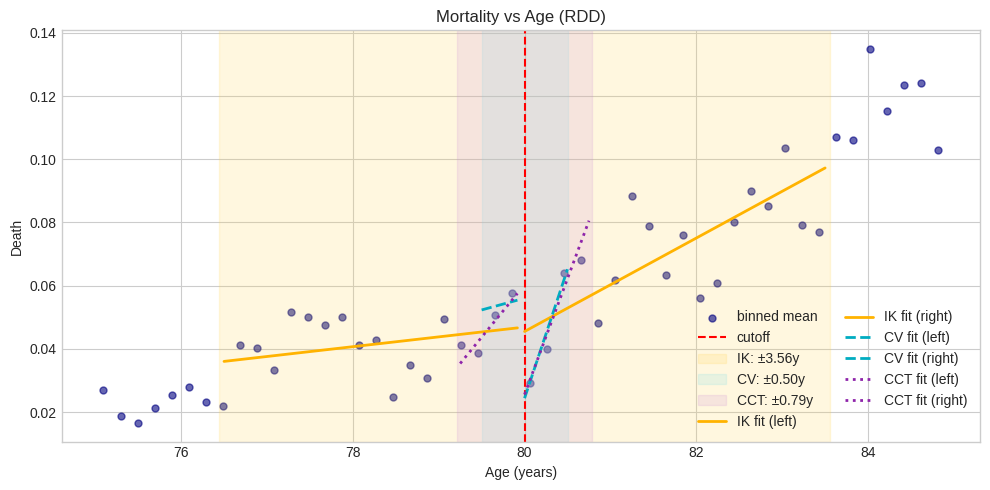

In [18]:
# -------------------------------------------------
# Figure 2: Mortality vs Age
# -------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(10, 5))

# Scatter + binned means
binned_scatter(ax2, df_rd["age_years"], df_rd["death"], bins=50, label="binned mean", color="navy")

# Cutoff and shaded bandwidths
ax2.axvline(80.0, color="red", linestyle="--", label="cutoff")
ax2.axvspan(80.0 - h_ik,  80.0 + h_ik,  color="#ffd54f", alpha=0.18, label=f"IK: ±{h_ik:.2f}y")
ax2.axvspan(80.0 - h_cv,  80.0 + h_cv,  color="#80deea", alpha=0.18, label=f"CV: ±{h_cv:.2f}y")
ax2.axvspan(80.0 - h_cct, 80.0 + h_cct, color="#ce93d8", alpha=0.18, label=f"CCT: ±{h_cct:.2f}y")

# Fitted lines for each bandwidth
fit_lines_for_bandwidth(ax2, df_rd, outcome="death", h=h_ik,  color="#ffb300", linestyle="-",  label_prefix="IK")
fit_lines_for_bandwidth(ax2, df_rd, outcome="death", h=h_cv,  color="#00acc1", linestyle="--", label_prefix="CV")
fit_lines_for_bandwidth(ax2, df_rd, outcome="death", h=h_cct, color="#8e24aa", linestyle=":",  label_prefix="CCT")

ax2.set_title("Mortality vs Age (RDD)")
ax2.set_xlabel("Age (years)")
ax2.set_ylabel("Death")
ax2.legend(loc="lower right", ncol=2)
plt.tight_layout()
plt.show()

In [19]:
covariates = ["sex_male", "comorbidity", "imd"]
placebo_results = []
for cov in covariates:
    tau_cov, se_cov, n_eff_cov, _ = local_linear_wls(df_rd, outcome=cov, h=h_cct, cutoff=0.0, include_quad=False, treatment_name="elig")
    t_stat = tau_cov / se_cov if se_cov not in [0, np.nan] else np.nan
    p_val = 2 * (1 - stats.t.cdf(np.abs(t_stat), df=int(max(n_eff_cov - 3, 1)))) if not np.isnan(t_stat) else np.nan
    placebo_results.append({
        "Covariate": cov,
        "Tau": tau_cov,
        "SE": se_cov,
        "n_eff": n_eff_cov,
        "p_value": p_val
    })
placebo_df = pd.DataFrame(placebo_results)
print("\n=== Placebo discontinuities in covariates at cutoff (CCT bandwidth) ===")
display(placebo_df.round(4))


=== Placebo discontinuities in covariates at cutoff (CCT bandwidth) ===


,Covariate,Tau,SE,n_eff,p_value
0,sex_male,-0.0058,0.0387,1625.5606,0.8811
1,comorbidity,-0.0346,0.0814,1625.5606,0.6713
2,imd,-0.0491,0.0929,1625.5606,0.5972


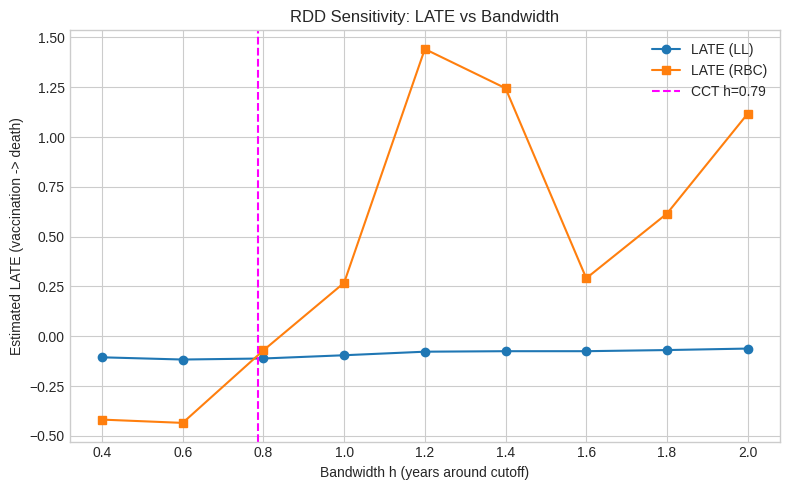

In [20]:
results_sens = []
for h in np.linspace(0.4, 2.0, 9):
    rf_tau_rbc_h, rf_tau_ll_h, rf_se_ll_h, rf_n_eff_h, rf_bias_h = rbc_estimate(df_rd, outcome="death", h=h)
    fs_tau_rbc_h, fs_tau_ll_h, fs_se_ll_h, fs_n_eff_h, fs_bias_h = rbc_estimate(df_rd, outcome="vaccinated", h=h)
    late_ll_h = rf_tau_ll_h / fs_tau_ll_h if fs_tau_ll_h != 0 else np.nan
    late_rbc_h = rf_tau_rbc_h / fs_tau_rbc_h if fs_tau_rbc_h != 0 else np.nan
    results_sens.append({
        "h": h,
        "RF_LL": rf_tau_ll_h,
        "RF_RBC": rf_tau_rbc_h,
        "FS_LL": fs_tau_ll_h,
        "FS_RBC": fs_tau_rbc_h,
        "LATE_LL": late_ll_h,
        "LATE_RBC": late_rbc_h,
        "RF_bias_hat": rf_bias_h,
        "FS_bias_hat": fs_bias_h,
        "n_eff_RF": rf_n_eff_h,
        "n_eff_FS": fs_n_eff_h
    })
sens_df = pd.DataFrame(results_sens)

fig2, ax2 = plt.subplots(1, 1, figsize=(8, 5))
ax2.plot(sens_df["h"], sens_df["LATE_LL"], marker='o', label="LATE (LL)")
ax2.plot(sens_df["h"], sens_df["LATE_RBC"], marker='s', label="LATE (RBC)")
ax2.axvline(h_cct, color='magenta', linestyle='--', label=f"CCT h={h_cct:.2f}")
ax2.set_xlabel("Bandwidth h (years around cutoff)")
ax2.set_ylabel("Estimated LATE (vaccination -> death)")
ax2.set_title("RDD Sensitivity: LATE vs Bandwidth")
ax2.legend()
plt.tight_layout()
plt.show()